<a href="https://colab.research.google.com/github/sreelakshmisajeevan-854/Data-science/blob/main/Toyota-Corolla-Price-Prediction-MLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Datasets/ToyotaCorolla - MLR.csv')

In [ ]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [ ]:
df.tail()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015
1435,6950,76,1,Petrol,110,0,1600,5,4,5,1114


In [ ]:
df.shape

(1436, 11)

In [ ]:
df.select_dtypes(include=np.number).columns.to_list()

['Price',
 'Age_08_04',
 'KM',
 'HP',
 'Automatic',
 'cc',
 'Doors',
 'Cylinders',
 'Gears',
 'Weight']

In [ ]:
df.select_dtypes(include=object).columns.to_list()

['Fuel_Type']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


The dataset contains 1436 observations and 11 variables(10 numerical and 1 categorical). Numerical variables are stored as int64, while categorical variable is stored as object.

In [ ]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


No missing values are present in the dataset.

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

Duplicate rows are removed.

In [ ]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.0,1435.000000,1435.000000
mean,10720.915679,55.980488,68571.782578,101.491986,0.055749,1576.560976,4.032753,4.0,5.026481,1072.287108
std,3608.732978,18.563312,37491.094553,14.981408,0.229517,424.387533,0.952667,0.0,0.188575,52.251882
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.000000,2.000000,4.0,3.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.000000,3.000000,4.0,5.000000,1040.000000
50%,9900.000000,61.000000,63451.000000,110.000000,0.000000,1600.000000,4.000000,4.0,5.000000,1070.000000
75%,11950.000000,70.000000,87041.500000,110.000000,0.000000,1600.000000,5.000000,4.0,5.000000,1085.000000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.000000,5.000000,4.0,6.000000,1615.000000


In [ ]:
df.mean(numeric_only=True)

,0
Price,10720.915679
Age_08_04,55.980488
KM,68571.782578
HP,101.491986
Automatic,0.055749
cc,1576.560976
Doors,4.032753
Cylinders,4.000000
Gears,5.026481
Weight,1072.287108




*   The average Toyota Corolla in this dataset is priced around 10,721, is about 56 months old, and has been driven approximately 68,572 km.
*   Most vehicles have 4 doors, 4 cylinders, 5 gears, an engine capacity of around 1576 cc, and weigh about 1072 kg.
*   The dataset is dominated by manual transmission cars, with only about 5.6% being automatic.






In [ ]:
df.median(numeric_only=True)

,0
Price,9900.0
Age_08_04,61.0
KM,63451.0
HP,110.0
Automatic,0.0
cc,1600.0
Doors,4.0
Cylinders,4.0
Gears,5.0
Weight,1070.0




*   Price and KM are positively skewed because their means are greater than their medians.


*   HP is slightly negatively skewed because its mean is lower than its median.

*   cc, Doors, Cylinders, Gears, and Weight have mean and median values that are close, indicating relatively stable distributions with fewer extreme values.






In [ ]:
df.mode(numeric_only=True)

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,8950,68,36000,110,0,1600,5,4,5,1075


In [ ]:
df.std(numeric_only=True)

,0
Price,3608.732978
Age_08_04,18.563312
KM,37491.094553
HP,14.981408
Automatic,0.229517
cc,424.387533
Doors,0.952667
Cylinders,0.000000
Gears,0.188575
Weight,52.251882




*   KM has the highest standard deviation (37,491.09), indicating that the mileage of the cars varies the most.
*   Doors, Automatic, and Gears have low variability, meaning most vehicles share similar characteristics for these features.





<Axes: >

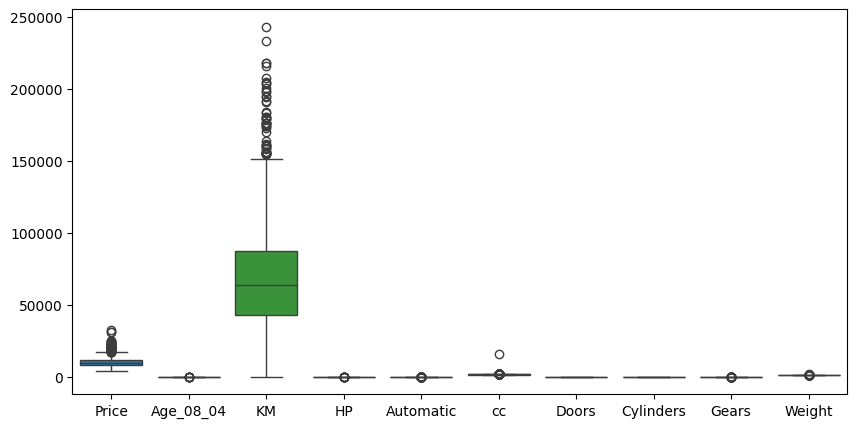

In [ ]:
fig=plt.figure(figsize=(10,5))
sns.boxplot(df)



*   KM has a greater outliers.



In [ ]:
for col in df.select_dtypes(include=np.number).columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  IQR=q3-q1
  upper=q3+1.5*IQR
  lower=q1-1.5*IQR
  df[col]=df[col].clip(lower,upper)

<Axes: >

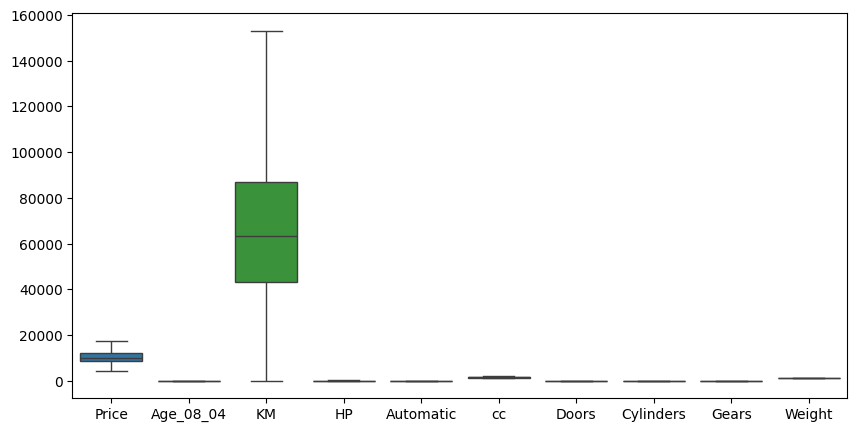

In [ ]:
fig=plt.figure(figsize=(10,5))
sns.boxplot(df)

Outliers are handled by using lower and upper fence

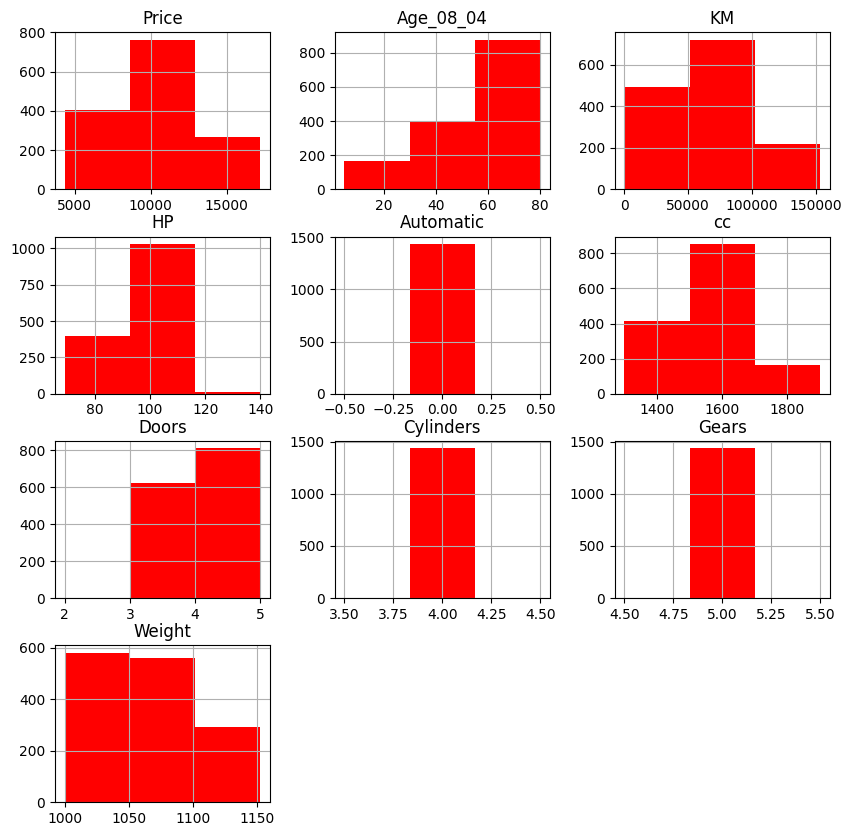

In [ ]:
df.hist(figsize=(10,10),bins=3,color='red')
plt.show()



*   Most numerical variables show a reasonable distribution with no severe irregularities.
*   Price and KM exhibit right-skewed distributions, indicating a few cars with exceptionally high prices or mileage.

*   Age_08_04 is concentrated around older vehicles, reflecting that the dataset mainly contains used cars.
*   List item





<Axes: xlabel='Price', ylabel='Age_08_04'>

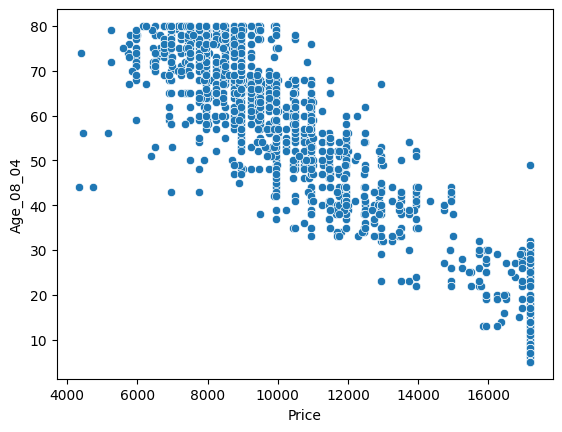

In [ ]:
sns.scatterplot(x='Price',y='Age_08_04',data=df)



*   The scatter plot shows a strong negative linear relationship between Age_08_04 and Price. Older cars generally have lower prices, indicating that age is an important factor affecting the resale value of Toyota Corolla cars.



<Axes: xlabel='Price', ylabel='KM'>

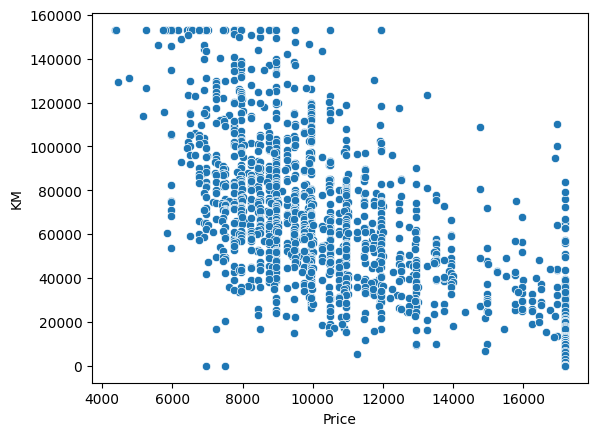

In [ ]:
sns.scatterplot(x='Price',y='KM',data=df)



*   The scatter plot indicates a negative relationship between KM and Price. Cars with higher mileage tend to have lower resale prices because increased usage reduces the vehicle's value.

*   Price in range 70000-13000,more vehicles are there





<Axes: >

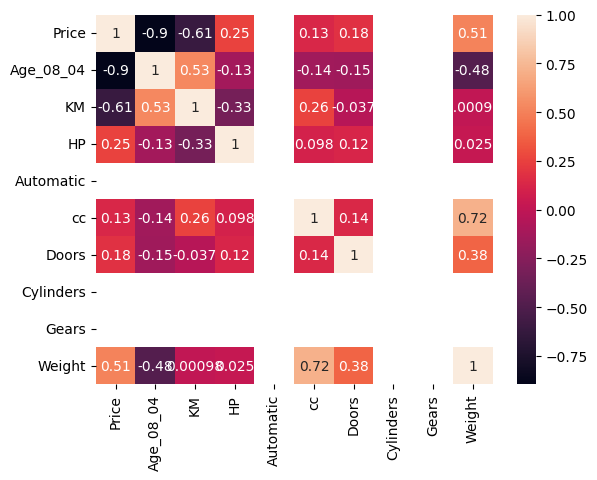

In [ ]:
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)



*   The correlation analysis shows that Age_08_04 has the strongest negative relationship with Price (r = -0.90), indicating that older cars have lower resale values.   
*   KM also has a moderate negative correlation with Price, while Weight shows a moderate positive correlation.


*   Among the independent variables, cc and Weight exhibit a strong positive correlation (r = 0.72), suggesting that larger engine capacity is associated with heavier vehicles.
*   Overall, Age_08_04, KM, and Weight appear to be important predictors for building the Multiple Linear Regression model.





In [ ]:
#Encoding
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [ ]:
df

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,86,0,1300,3,4,5,1025,False,True
1432,10845,72,19000,86,0,1300,3,4,5,1015,False,True
1433,8500,71,17016,86,0,1300,3,4,5,1015,False,True
1434,7250,70,16916,86,0,1300,3,4,5,1015,False,True


In [ ]:
df[['Fuel_Type_Diesel', 'Fuel_Type_Petrol']] = df[['Fuel_Type_Diesel', 'Fuel_Type_Petrol']].astype(int)

In [ ]:
df.head(10)


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986.0,90,0,1900,3,4,5,1152.5,1,0
1,13750,23,72937.0,90,0,1900,3,4,5,1152.5,1,0
2,13950,24,41711.0,90,0,1900,3,4,5,1152.5,1,0
3,14950,26,48000.0,90,0,1900,3,4,5,1152.5,1,0
4,13750,30,38500.0,90,0,1900,3,4,5,1152.5,1,0
5,12950,32,61000.0,90,0,1900,3,4,5,1152.5,1,0
6,16900,27,94612.0,90,0,1900,3,4,5,1152.5,1,0
7,17200,30,75889.0,90,0,1900,3,4,5,1152.5,1,0
8,17200,27,19700.0,140,0,1800,3,4,5,1152.5,0,1
9,12950,23,71138.0,69,0,1900,3,4,5,1105.0,1,0


## Model 1

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error
from sklearn.linear_model import LinearRegression
X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
#Define linear regression model
model = LinearRegression()
#Train the model
model.fit(X_train, y_train)
#Interpret the coefficients of the model.
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)
print("Intercept:", model.intercept_)


             Feature   Coefficient
0          Age_08_04 -1.049554e+02
1                 KM -1.485774e-02
2                 HP  2.999352e+01
3          Automatic  2.131628e-14
4                 cc -2.730928e+00
5              Doors -1.284072e+02
6          Cylinders -3.126388e-13
7              Gears -2.273737e-13
8             Weight  2.563973e+01
9   Fuel_Type_Diesel  9.460781e+02
10  Fuel_Type_Petrol  1.009305e+03
Intercept: -9284.784429719397


In [ ]:
#Predict the model
y_pred=model.predict(X_test)

#Get the metrics-scores
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(f'R2 score: {round(r2,2)}')
print(f'MSE: {round(mse,2)}')
print(f'RMSE: {round(rmse,2)}')

R2 score: 0.85
MSE: 1275108.72
RMSE: 1129.21


# Model 2

In [ ]:
X2 = df[['Age_08_04','KM','HP','Weight']]
#Split the dataset into training and testing sets (e.g., 80% training, 20% testing).
X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y,
    test_size=0.2,
    random_state=42
)
#Define linear regression model
model = LinearRegression()
#Train the model
model.fit(X2_train, y_train)
#Interpret the coefficients of the model.
coefficients = pd.DataFrame({
    'Feature': X2.columns,
    'Coefficient': model.coef_
})

print(coefficients)
print("Intercept:", model.intercept_)

     Feature  Coefficient
0  Age_08_04  -108.421141
1         KM    -0.018867
2         HP    22.312449
3     Weight    14.401623
Intercept: 183.20013453987121


In [ ]:
#Predict the model
y_pred=model.predict(X2_test)

#Get the metrics-scores
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(f'R2 score: {round(r2,2)}')
print(f'MSE: {round(mse,2)}')
print(f'RMSE: {round(rmse,2)}')

R2 score: 0.85
MSE: 1305481.43
RMSE: 1142.58


# Model 3

In [ ]:
X3 = df[['Age_08_04','KM','Weight','Fuel_Type_Diesel','Fuel_Type_Petrol']]
X3_train, X3_test, y_train, y_test = train_test_split(
    X3, y,
    test_size=0.2,
    random_state=42
)
#Define linear regression model
model = LinearRegression()
#Train the model
model.fit(X3_train, y_train)
#Interpret the coefficients of the model.
coefficients = pd.DataFrame({
    'Feature': X3.columns,
    'Coefficient': model.coef_
})

print(coefficients)
print("Intercept:", model.intercept_)


            Feature  Coefficient
0         Age_08_04  -107.609135
1                KM    -0.015929
2            Weight    22.691090
3  Fuel_Type_Diesel  -738.729860
4  Fuel_Type_Petrol   886.887882
Intercept: -7364.823205147377


In [ ]:
#Predict the model
y_pred=model.predict(X3_test)

#Get the metrics-scores
mean_squared_error
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(f'R2 score: {round(r2,2)}')
print(f'MSE: {round(mse,2)}')
print(f'RMSE: {round(rmse,2)}')

R2 score: 0.85
MSE: 1264486.82
RMSE: 1124.49


Among the three Multiple Linear Regression models, Model 2 performed the best with an R² score of 0.85, indicating that it explains 85% of the variation in the car prices. It also achieved the lowest MSE (1,993,321.01) and lowest RMSE (1,411.85), showing the highest prediction accuracy. This indicates that the variables Age_08_04, KM, HP, and Weight are sufficient to build an effective regression model for predicting the price of Toyota Corolla cars. Models 1 and 3 performed reasonably well but had higher prediction errors compared to Model 2.

# Ridge

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

In [ ]:
ridge2 = Ridge(alpha=1.0)

ridge2.fit(X2_train_scaled, y_train)

ridge2_pred = ridge2.predict(X2_test_scaled)
mean_squared_error
mse=mean_squared_error(y_test,ridge2_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(f'R2 score: {round(r2,2)}')
print(f'MSE: {round(mse,2)}')
print(f'RMSE: {round(rmse,2)}')

R2 score: 0.85
MSE: 1305757.45
RMSE: 1142.7


# Lasso

In [ ]:
lasso2 = Lasso(alpha=1.0)

lasso2.fit(X2_train_scaled, y_train)

lasso2_pred = lasso2.predict(X2_test_scaled)
mean_squared_error
mse=mean_squared_error(y_test,lasso2_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(f'R2 score: {round(r2,2)}')
print(f'MSE: {round(mse,2)}')
print(f'RMSE: {round(rmse,2)}')

R2 score: 0.85
MSE: 1305293.28
RMSE: 1142.49


The performance of Multiple Linear Regression, Ridge Regression, and Lasso Regression was evaluated using R² Score, MSE, and RMSE. All three models achieved an R² score of approximately 0.82, indicating that they explain about 82% of the variation in the car prices. Ridge Regression produced the lowest MSE (1,993,007.04) and lowest RMSE (1,411.74), making it the best-performing model among the three, although the improvement over Multiple Linear Regression was very small. Lasso Regression showed similar performance, indicating that regularization had only a minor effect on this dataset.

## Interview Questions:
```

1.What is Normalization & Standardization and how is it helpful?
   Standardization transforms data so that it has a mean of 0 and a standard deviation of 1, while normalization scales data to a fixed range, usually 0 to 1. Both methods make features comparable, improve model performance, and are especially useful for algorithms such as Ridge and Lasso Regression.
2.What techniques can be used to address multicollinearity in multiple linear regression?
   Multicollinearity occurs when two or more independent variables are highly correlated with each other. It can make coefficient estimates unstable and difficult to interpret.
   Techniques to address multicollinearity include:
   1.Remove highly correlated variables
   2.Check Variance Inflation Factor (VIF)
   3.Principal Component Analysis (PCA)
       PCA transforms correlated variables into a smaller set of uncorrelated principal components.
   4.Ridge Regression
       Ridge regression adds an L2 penalty to the regression model.
   5.Lasso Regression
       Lasso regression adds an L1 penalty.
   

```


